В файле «vgsale_1.csv» содержатся данные о видеоиграх, выпущенных с
1980 по 2020 гг. В файле представлены 16598 наблюдений, каждое из которых
имеет 10 характеристик:
 - Name – название игры,
 - Platform – игровая платформа (PC, PSP, X360 и др.),
 - Year – год выпуска игры,
 - Genre – жанр игры,
 - Publisher – издатель игры,
 - NA_Sales – продажи в Северной Америке (в миллионах),
 - EU_Sales – продажи в Европе (в миллионах),
 - JP_Sales – продажи в Японии (в миллионах),
 - Other_Sales – продажи в остальных странах мира (в миллионах),
 - Global_Sales – объем продаж по всему миру.
Загрузите файл «vgsales.csv» в объект DataFrame, рассчитайте необходимые
показатели и визуализируйте информацию, используя различные
инструменты pandas. Проанализируйте полученные графики и сделайте
выводы.

In [1]:
import pandas as pd
import numpy as np


df = pd.read_csv("vgsale_1.csv", sep=',')
df

,Name,Platform,Year,Genre,Publisher,NA_Sales,EU_Sales,JP_Sales,Other_Sales,Global_Sales
0,Wii Sports,Wii,2006.0,Sports,Nintendo,41.49,29.02,3.77,8.46,82.74
1,Super Mario Bros.,NES,1985.0,Platform,Nintendo,29.08,3.58,6.81,0.77,40.24
2,Mario Kart Wii,Wii,2008.0,Racing,Nintendo,15.85,12.88,3.79,3.31,35.82
3,Wii Sports Resort,Wii,2009.0,Sports,Nintendo,15.75,11.01,3.28,2.96,33.00
4,Pokemon Red/Pokemon Blue,GB,1996.0,Role-Playing,Nintendo,11.27,8.89,10.22,1.00,31.37
...,...,...,...,...,...,...,...,...,...,...
16593,Woody Woodpecker in Crazy Castle 5,GBA,2002.0,Platform,Kemco,0.01,0.00,0.00,0.00,0.01
16594,Men in Black II: Alien Escape,GC,2003.0,Shooter,Infogrames,0.01,0.00,0.00,0.00,0.01
16595,SCORE International Baja 1000: The Official Game,PS2,2008.0,Racing,Activision,0.00,0.00,0.00,0.00,0.01
16596,Know How 2,DS,2010.0,Puzzle,7G//AMES,0.00,0.01,0.00,0.00,0.01


In [2]:
df.info()
df['Year'] = pd.to_numeric(df['Year'], errors='coerce')
df = df.dropna(subset=['Year']).copy()
df['Year'] = df['Year'].astype(int)

for col in ['NA_Sales','EU_Sales','JP_Sales','Other_Sales','Global_Sales']:
    df[col] = pd.to_numeric(df[col], errors='coerce').fillna(0.0)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 16598 entries, 0 to 16597
Data columns (total 10 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Name          16598 non-null  object 
 1   Platform      16598 non-null  object 
 2   Year          16327 non-null  float64
 3   Genre         16598 non-null  object 
 4   Publisher     16540 non-null  object 
 5   NA_Sales      16598 non-null  float64
 6   EU_Sales      16598 non-null  float64
 7   JP_Sales      16598 non-null  float64
 8   Other_Sales   16598 non-null  float64
 9   Global_Sales  16598 non-null  float64
dtypes: float64(6), object(4)
memory usage: 1.3+ MB


1.Игры каких жанров были наиболее популярны до 2000 года, а какие после?
Оцените популярность жанров по количеству выпущенных игр и по объему продаж по всему миру.
Для визуализации полученных результатов используйте столбиковые диаграммы.  
Замечание. Одна и та же игра может встречаться в выборке несколько раз, т.к. она может быть выпущена на нескольких платформах.

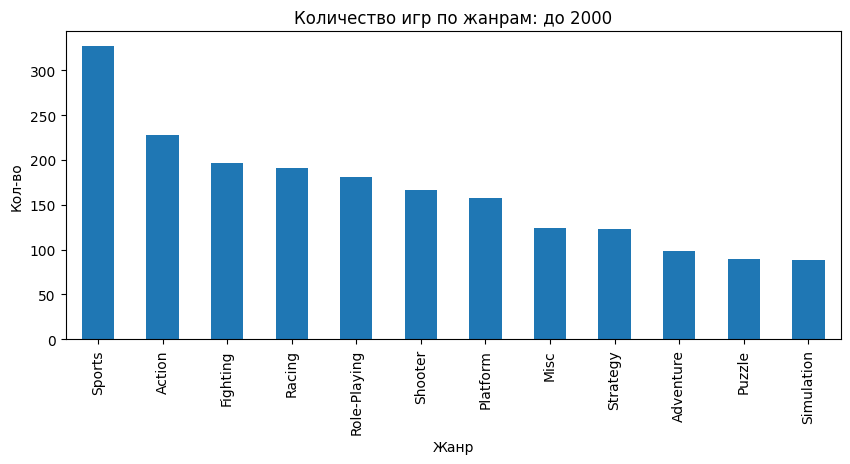

In [5]:
import matplotlib.pyplot as plt

pre = df[df['Year'] < 2000]
post = df[df['Year'] >= 2000]

cnt_pre = pre['Genre'].value_counts().sort_values(ascending=False)
cnt_post = post['Genre'].value_counts().sort_values(ascending=False)

ax = cnt_pre.plot(kind='bar', figsize=(10,4), title='Количество игр по жанрам: до 2000')
ax.set_xlabel('Жанр'); ax.set_ylabel('Кол-во'); plt.show()

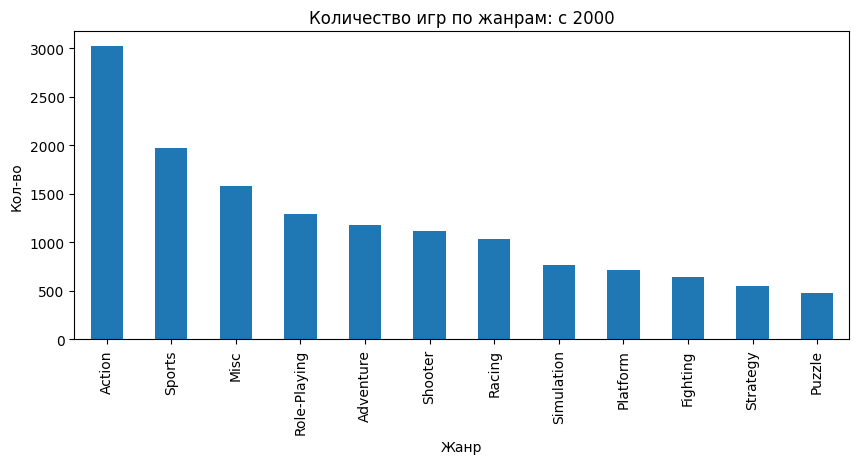

In [6]:
ax = cnt_post.plot(kind='bar', figsize=(10,4), title='Количество игр по жанрам: с 2000')
ax.set_xlabel('Жанр'); ax.set_ylabel('Кол-во'); plt.show()

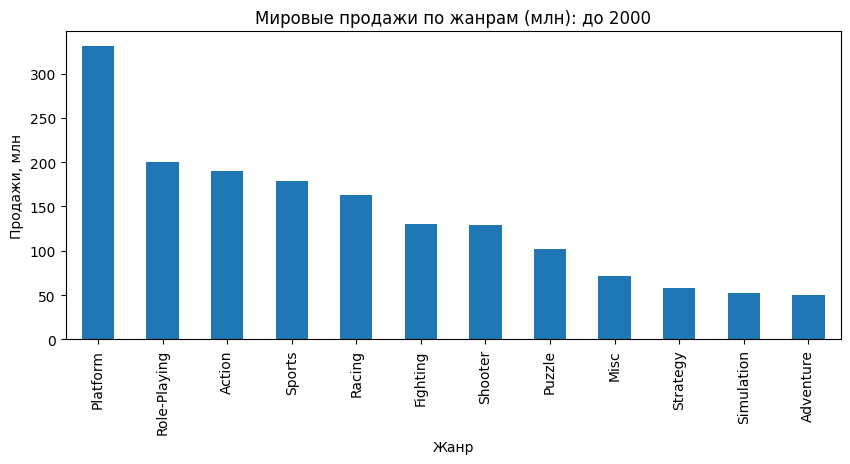

In [7]:
sales_pre = pre.groupby('Genre')['Global_Sales'].sum().sort_values(ascending=False)
sales_post = post.groupby('Genre')['Global_Sales'].sum().sort_values(ascending=False)

ax = sales_pre.plot(kind='bar', figsize=(10,4), title='Мировые продажи по жанрам (млн): до 2000')
ax.set_xlabel('Жанр'); ax.set_ylabel('Продажи, млн'); plt.show()

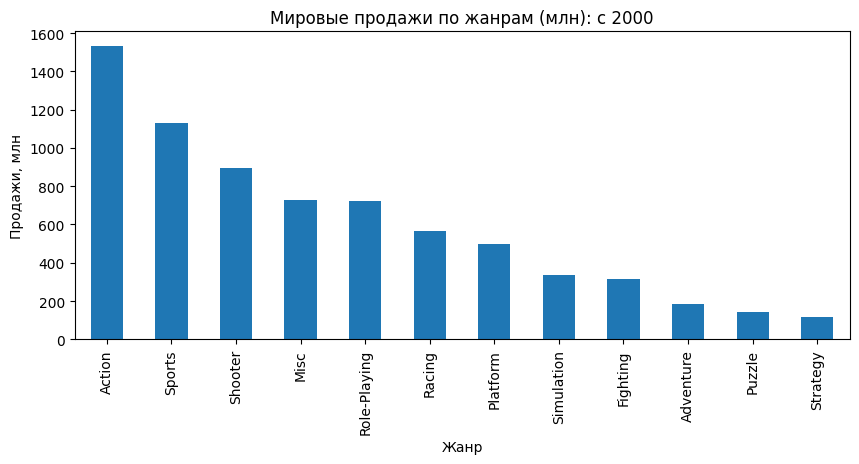

In [9]:
ax = sales_post.plot(kind='bar', figsize=(10,4), title='Мировые продажи по жанрам (млн): с 2000')
ax.set_xlabel('Жанр'); ax.set_ylabel('Продажи, млн'); plt.show()

In [10]:
pd.DataFrame({
    'count_pre2000': cnt_pre,
    'count_post2000': cnt_post,
    'sales_pre2000': sales_pre,
    'sales_post2000': sales_post
}).fillna(0).astype({'count_pre2000':int,'count_post2000':int}).sort_values('count_post2000', ascending=False)


,count_pre2000,count_post2000,sales_pre2000,sales_post2000
Genre,,,,
Action,228,3025,190.47,1532.41
Sports,327,1977,178.85,1130.39
Misc,124,1586,71.99,725.63
Role-Playing,181,1290,199.77,724.07
Adventure,99,1177,49.59,185.21
Shooter,167,1115,128.74,897.46
Racing,191,1035,162.50,564.27
Simulation,89,762,52.56,337.60
Platform,158,718,331.18,497.97


2.Отобразите на графике общее число видеоигр, выпущенных в каждом году.

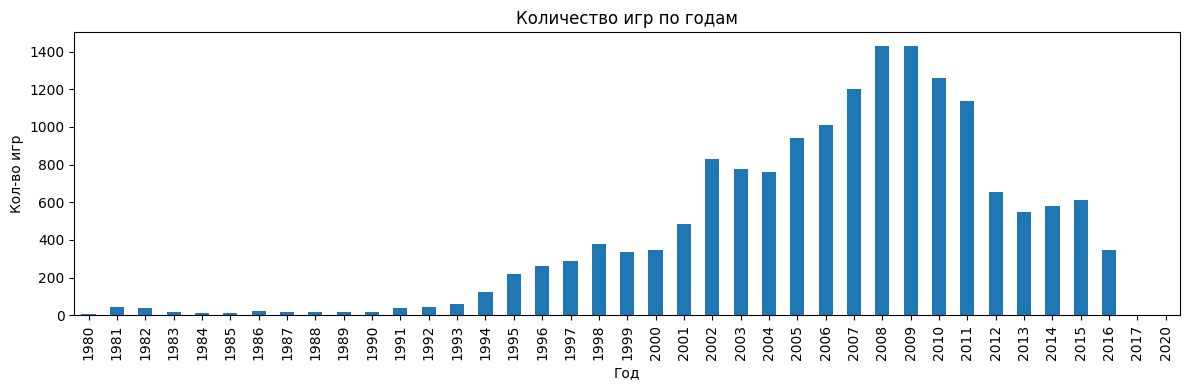

count      39.000000
mean      418.641026
std       451.735920
min         1.000000
25%        19.000000
50%       289.000000
75%       710.000000
max      1431.000000
Name: count, dtype: float64

In [11]:
games_per_year = df['Year'].value_counts().sort_index()

ax = games_per_year.plot(kind='bar', figsize=(12,4), title='Количество игр по годам')
ax.set_xlabel('Год'); ax.set_ylabel('Кол-во игр'); plt.tight_layout(); plt.show()

games_per_year.describe()

3.Определите трех издателей, выпустивших наибольшее количество видеоигр. Изобразите количество выпущенных издателями видеоигр для каждой платформы на столбиковой диаграмме (можно использовать диаграмму с накоплением).

In [12]:
top3_pub = df['Publisher'].value_counts().head(3).index.tolist()
top3_pub

['Electronic Arts', 'Activision', 'Namco Bandai Games']

In [13]:
pivot = (df[df['Publisher'].isin(top3_pub)]
         .pivot_table(index='Platform', columns='Publisher', values='Name', aggfunc='count', fill_value=0)
         .sort_values(by=top3_pub, ascending=False))

pivot.head(10)

Publisher,Activision,Electronic Arts,Namco Bandai Games
Platform,,,
PS2,103,196,107
X360,133,165,43
PC,55,147,11
PS3,108,141,115
XB,60,121,10
PS,32,106,48
Wii,109,89,56
GC,44,88,22
DS,110,79,135


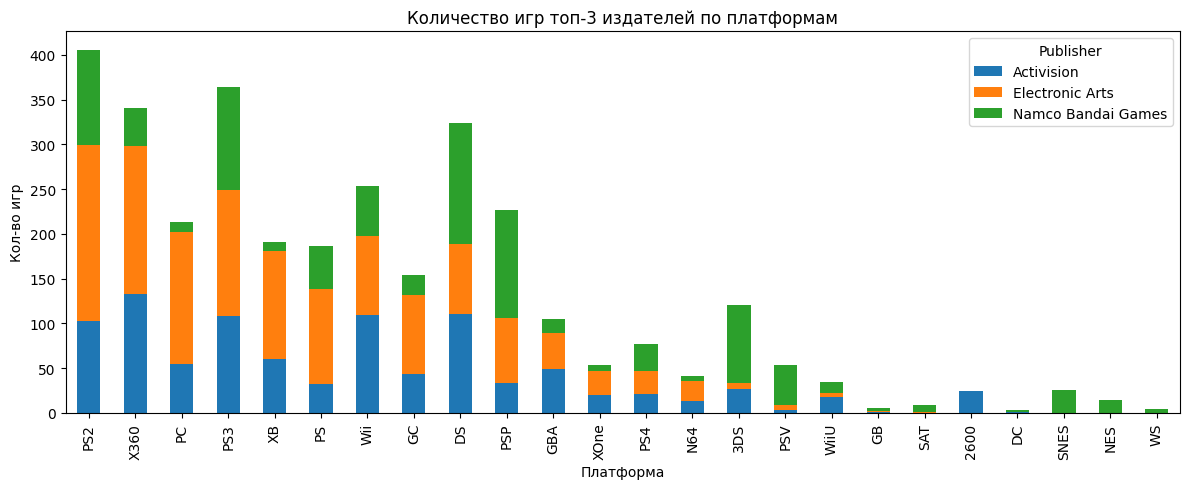

In [14]:
ax = pivot.plot(kind='bar', stacked=True, figsize=(12,5),
                title='Количество игр топ-3 издателей по платформам')
ax.set_xlabel('Платформа'); ax.set_ylabel('Кол-во игр'); plt.tight_layout(); plt.show()

4.Отобразите на круговых диаграммах доли суммарного объема продаж с 1980г. до 2000г. и с 2000г. до 2020г. в Северной Америке, Европе, Японии от объема продаж по всему миру

In [25]:
df_3 = df[df['Year'].isin(range(1980,2000))]
df_3

,Name,Platform,Year,Genre,Publisher,NA_Sales,EU_Sales,JP_Sales,Other_Sales,Global_Sales
1,Super Mario Bros.,NES,1985,Platform,Nintendo,29.08,3.58,6.81,0.77,40.24
4,Pokemon Red/Pokemon Blue,GB,1996,Role-Playing,Nintendo,11.27,8.89,10.22,1.00,31.37
5,Tetris,GB,1989,Puzzle,Nintendo,23.20,2.26,4.22,0.58,30.26
9,Duck Hunt,NES,1984,Shooter,Nintendo,26.93,0.63,0.28,0.47,28.31
12,Pokemon Gold/Pokemon Silver,GB,1999,Role-Playing,Nintendo,9.00,6.18,7.20,0.71,23.10
...,...,...,...,...,...,...,...,...,...,...
16379,Grand Prix Legends,PC,1997,Racing,Vivendi Games,0.00,0.01,0.00,0.00,0.01
16436,Worms 2,PC,1997,Strategy,Microprose,0.00,0.01,0.00,0.00,0.01
16506,Samurai Shodown: Warrios Rage,PS,1999,Fighting,SNK,0.01,0.00,0.00,0.00,0.01
16554,Psychic Detective,PS,1995,Adventure,Electronic Arts,0.01,0.00,0.00,0.00,0.01


In [26]:
df_3[['NA_Sales', 'EU_Sales', 'JP_Sales', 'Other_Sales', 'Global_Sales']].apply(np.sum)

NA_Sales         811.77
EU_Sales         314.07
JP_Sales         474.82
Other_Sales       54.55
Global_Sales    1655.49
dtype: float64

In [27]:
s4 = df_3[['NA_Sales', 'EU_Sales', 'JP_Sales', 'Other_Sales']].apply(np.sum)

<Axes: >

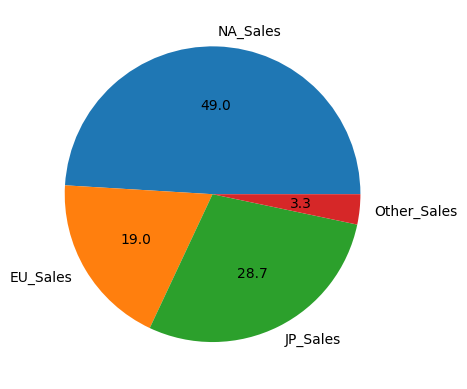

In [28]:
s4.plot.pie(autopct='%.1f')

C 2000 по 2020


<Axes: >

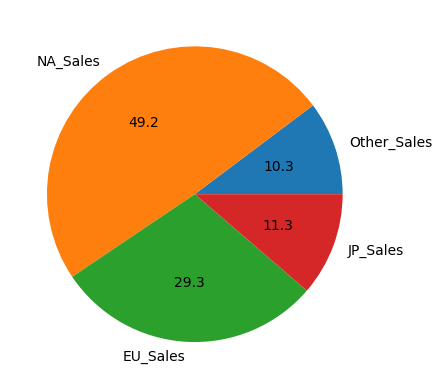

In [20]:
print('C 2000 по 2020')
df[(df['Year'] >= 2000) & (df['Year'] <= 2020)][['Other_Sales','NA_Sales','EU_Sales','JP_Sales']].sum().plot.pie(autopct='%.1f')

In [21]:
df_4 = df[df['Year'].isin(range(2000,2021))]
df_4

,Name,Platform,Year,Genre,Publisher,NA_Sales,EU_Sales,JP_Sales,Other_Sales,Global_Sales
0,Wii Sports,Wii,2006,Sports,Nintendo,41.49,29.02,3.77,8.46,82.74
2,Mario Kart Wii,Wii,2008,Racing,Nintendo,15.85,12.88,3.79,3.31,35.82
3,Wii Sports Resort,Wii,2009,Sports,Nintendo,15.75,11.01,3.28,2.96,33.00
6,New Super Mario Bros.,DS,2006,Platform,Nintendo,11.38,9.23,6.50,2.90,30.01
7,Wii Play,Wii,2006,Misc,Nintendo,14.03,9.20,2.93,2.85,29.02
...,...,...,...,...,...,...,...,...,...,...
16593,Woody Woodpecker in Crazy Castle 5,GBA,2002,Platform,Kemco,0.01,0.00,0.00,0.00,0.01
16594,Men in Black II: Alien Escape,GC,2003,Shooter,Infogrames,0.01,0.00,0.00,0.00,0.01
16595,SCORE International Baja 1000: The Official Game,PS2,2008,Racing,Activision,0.00,0.00,0.00,0.00,0.01
16596,Know How 2,DS,2010,Puzzle,7G//AMES,0.00,0.01,0.00,0.00,0.01


In [22]:
df_4[['NA_Sales', 'EU_Sales', 'JP_Sales', 'Other_Sales', 'Global_Sales']].apply(np.sum)

NA_Sales        3521.66
EU_Sales        2095.05
JP_Sales         809.48
Other_Sales      734.46
Global_Sales    7164.87
dtype: float64